# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [ ]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [4]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [ ]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)



## 1. Đơn Vị Quan Sát (Observation Unit)
* **Định nghĩa:** Mỗi dòng dữ liệu đại diện cho thông tin của **một khách hàng bán buôn**.
* **Đối tượng cụ thể:** Có thể là nhà hàng, khách sạn, hoặc các cửa hàng tạp hóa bán lẻ.
* **Ý nghĩa đặc trưng:** Các biến số về chi tiêu (`Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicaten`) phản ánh trực tiếp **quy mô** và **loại hình kinh doanh** của khách hàng đó.

---

## 2. Kết Quả Audit Dữ Liệu (Data Audit)

###  Giá trị thiếu (Missing Values)
* **Trạng thái:** Dữ liệu hoàn toàn sạch, **không có** giá trị thiếu (Missing values). 
* **Hành động:** Không cần thực hiện các biện pháp điền khuyết dữ liệu (imputation).

###  Điểm cực trị (Outliers)
* **Hiện tượng:** Trong dữ liệu chi tiêu ngành bán buôn, luôn xuất hiện các "đại gia" với mức chi tiêu vượt trội, gấp hàng chục lần so với mức trung bình của thị trường.
* **Hệ quả:** Nếu giữ nguyên, các điểm cực trị này sẽ kéo lệch trọng tâm (*centroid*) của các thuật toán phân cụm (như K-Means), làm giảm độ chính xác của mô hình.
* **Hành động:** Cần áp dụng các phương pháp xử lý nhiễu/outliers (ví dụ: Log Transformation, Robust Scaling, hoặc loại bỏ theo phương pháp IQR) trước khi tiến hành phân cụm.

---

## 3. Xử Lý Các Biến Phân Loại (Channel / Region)

* **Bản chất biến:** `Channel` và `Region` là các biến phân loại (*Categorical variables*) đã được mã hóa dưới dạng số (ví dụ: 1, 2, 3).
* **Chiến lược xử lý:** **Không đưa** hai biến này vào làm dữ liệu đầu vào (*Input features*) của mô hình phân cụm ban đầu.

>  **Lý do toán học:** Khoảng cách giữa "Channel 1" và "Channel 2" chỉ là 1 đơn vị, hoàn toàn không có tính tương đồng vật lý hay giá trị định lượng để so sánh trực tiếp với khoảng cách hàng nghìn đô la của các biến chi tiêu. Việc đưa vào sẽ làm méo mó ma trận khoảng cách của mô hình.

* **Vai trò hậu phân cụm:** Sau khi thuật toán tìm ra các cụm khách hàng dựa trên hành vi chi tiêu, chúng ta sẽ dùng `Channel` và `Region` để kiểm chứng, đối chiếu xem các cụm tự nhiên này có trùng khớp với kênh phân phối hoặc khu vực địa lý thực tế hay không.

---

## 4. Giá Trị Doanh Nghiệp (Business Value)

Mục tiêu tối thượng của bài toán Segmentation này không chỉ là phân nhóm toán học, mà là tạo ra **giá trị thực tế cho doanh nghiệp**:

* **Tối ưu hóa chiến dịch Marketing:** Giúp đội ngũ Marketing định hình rõ ràng chân dung khách hàng, biết chính xác nên chào mời mặt hàng gì cho nhóm nào.
* **Ví dụ thực tế:** 
  * Nhóm có chi tiêu đột biến cho ngành hàng `Fresh` $\rightarrow$ Nhận diện là **Nhà hàng tươi sống** $\rightarrow$ Tập trung chiến dịch quảng cáo thực phẩm tươi, ưu đãi vận chuyển nhanh.
  * Nhóm chi mạnh cho `Grocery` và `Detergents_Paper` $\rightarrow$ Nhận diện là **Cửa hàng tạp hóa/Siêu thị mini** $\rightarrow$ Áp dụng chính sách chiết khấu số lượng lớn, tặng kèm kệ trưng bày.


# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

Độ lệch của các tính năng:
Fresh               2.56
Milk                4.05
Grocery             3.59
Frozen              5.91
Detergents_Paper    3.63
Delicassen         11.15
dtype: float64


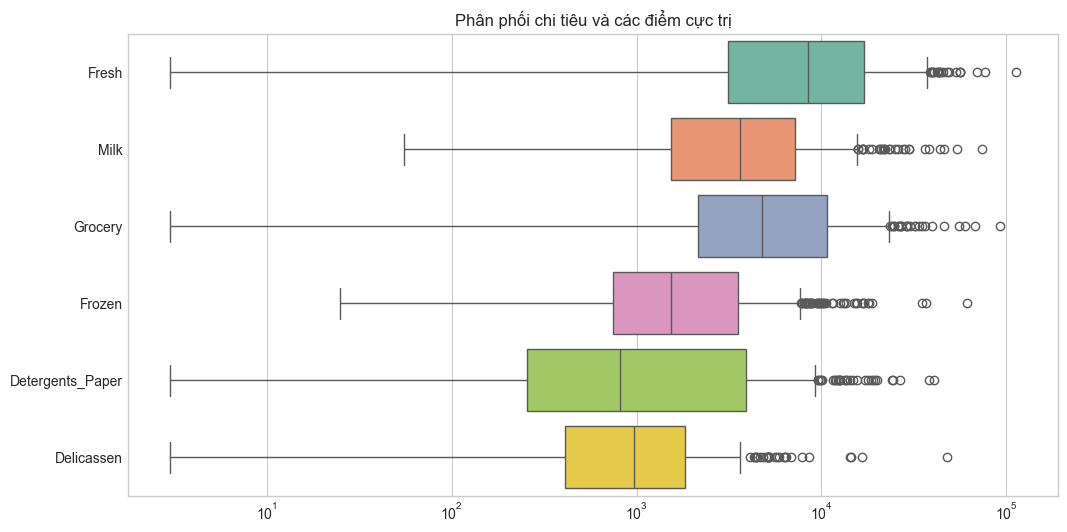

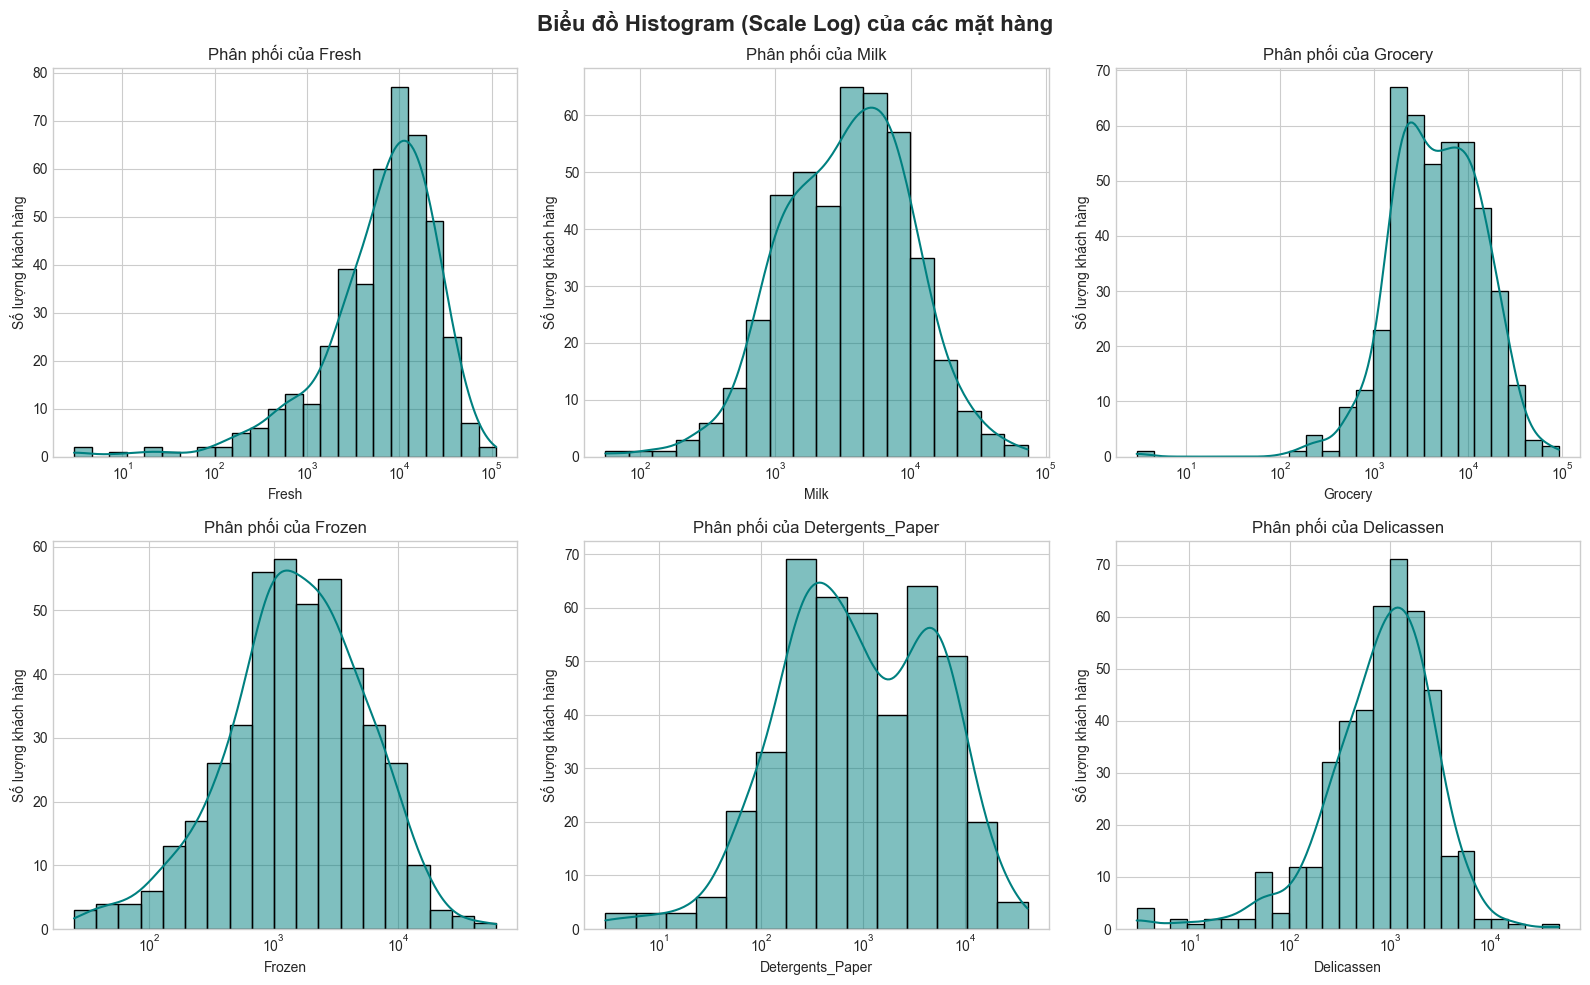

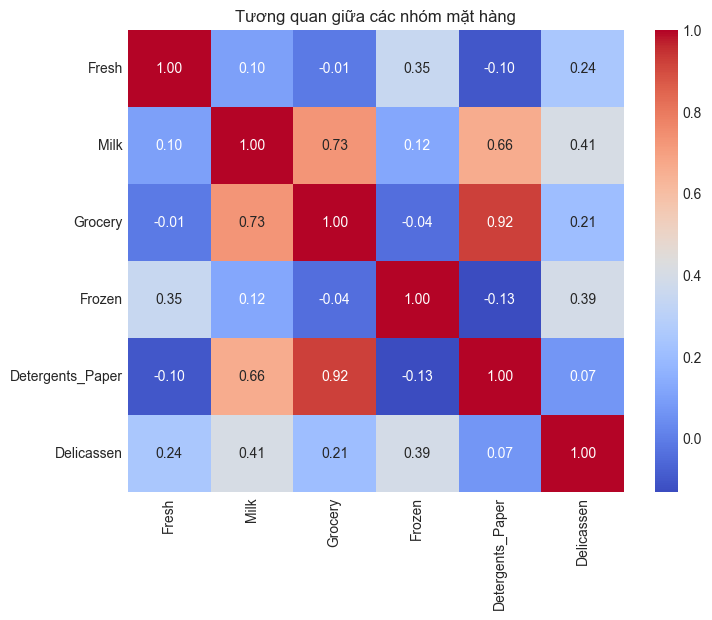

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Kiểm tra độ lệch (Skewness)
print("Độ lệch của các tính năng:")
print(X_raw.skew())

#  Vẽ boxplot để quan sát Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_raw, orient='h', palette='Set2')
plt.title("Phân phối chi tiêu và các điểm cực trị")
plt.xscale('log') # Dùng scale log để nhìn thấy các điểm nhỏ và lớn cùng lúc
plt.show()

# Vẽ Histogram cho từng nhóm mặt hàng
fig, axes = plt.subplots(2, 3, figsize=(16, 10)) # Tạo lưới 2 hàng, 3 cột
axes = axes.flatten() # Phẳng hóa mảng để duyệt vòng lặp dễ dàng

for i, col in enumerate(X_raw.columns):
    # Vẽ histogram có đường cong KDE và tự động chỉnh thang đo Log để biểu đồ không bị lệch
    sns.histplot(X_raw[col], kde=True, log_scale=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Phân phối của {col}")
    axes[i].set_ylabel("Số lượng khách hàng")

plt.suptitle("Biểu đồ Histogram (Scale Log) của các mặt hàng", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Kiểm tra tương quan (Correlation)
plt.figure(figsize=(8, 6))
sns.heatmap(X_raw.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Tương quan giữa các nhóm mặt hàng")
plt.show()


# Phân tích phân phối và tương quan dữ liệu

## 1. Phân phối dữ liệu và độ lệch
* Thực tế: Dữ liệu chi tiêu bị lệch phải rất nặng, một số cột có độ lệch lớn hơn 10.
* Ý nghĩa: Hầu hết khách hàng chỉ chi tiêu ít, chỉ có một số ít khách hàng lớn chi tiêu cực kỳ nhiều.
* Giải pháp: Cần sử dụng phương pháp biến đổi Log (Log-transform) để đưa dữ liệu về trạng thái cân bằng trước khi phân cụm.

## 2. Tương quan giữa các mặt hàng
* Thực tế: Ba mặt hàng Milk, Grocery và Detergents Paper có mối tương quan rất mạnh với nhau, lớn hơn 0.7.
* Ý nghĩa: Khi một khách hàng mua nhiều bách hóa thì họ cũng có xu hướng mua nhiều sữa và chất tẩy rửa.
* Chân dung khách hàng: Nhóm này đại diện cho các cửa hàng bán lẻ hoặc siêu thị tạp hóa mini. Doanh nghiệp có thể dựa vào đây để thiết kế các gói combo sản phẩm phù hợp cho họ.


# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

In [9]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))

X_log = np.log1p(X_raw)

scaler = StandardScaler()
X_model = scaler.fit_transform(X_log)

X_model_df = pd.DataFrame(X_model, columns=SPENDING_FEATURES)

print("Dữ liệu đã sẵn sàng để fit model.")
display(pd.DataFrame(X_model, columns=SPENDING_FEATURES).head())


Dữ liệu đã sẵn sàng để fit model.


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.49,0.98,0.44,-1.51,0.64,0.41
1,0.09,0.99,0.65,0.13,0.77,0.63
2,0.02,0.89,0.45,0.38,0.80,1.78
3,0.52,-0.96,-0.08,1.14,-0.33,0.63
4,0.88,0.44,0.40,0.76,0.40,1.46


# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [13]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.model_selection import train_test_split


range_n_clusters = [2, 3, 4, 5, 6]

print(f"{'K':<5} | {'K-Means Sil':<12} | {'K-Means DB':<12} | {'Hierarch Sil':<12} | {'Hierarch DB':<12}")
print("-" * 75)

for k in range_n_clusters:
    # K-Means
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km_labels = km.fit_predict(X_model)
    km_sil = silhouette_score(X_model, km_labels)
    km_db = davies_bouldin_score(X_model, km_labels)
    
    # Agglomerative (Hierarchical)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg.fit_predict(X_model)
    agg_sil = silhouette_score(X_model, agg_labels)
    agg_db = davies_bouldin_score(X_model, agg_labels) 
    
    print(f"{k:<5} | {km_sil:<12.4f} | {km_db:<12.4f} | {agg_sil:<12.4f} | {agg_db:<12.4f}")



best_k = 3
model_final = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
labels_final = model_final.fit_predict(X_model)


X_sub1, X_sub2 = train_test_split(X_model, test_size=0.5, random_state=42)

# Chạy cụm trên nửa dữ liệu thứ nhất
km_sub1 = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_sub1 = km_sub1.fit_predict(X_sub1)

# Dự đoán nhãn của nửa dữ liệu thứ nhất dựa trên mô hình học từ nửa dữ liệu thứ hai
km_sub2 = KMeans(n_clusters=best_k, n_init=10, random_state=100) 
km_sub2.fit(X_sub2)
labels_sub2_predicted = km_sub2.predict(X_sub1) 

# Tính ARI để xem cấu trúc cụm giữa 2 nửa dữ liệu có đồng nhất không
ari_score = adjusted_rand_score(labels_sub1, labels_sub2_predicted)
print("-" * 70)
print(f"Độ ổn định của mô hình (ARI giữa 2 nửa dữ liệu): {ari_score:.4f}")

# Thống kê số lượng phần tử mỗi cụm của mô hình cuối
df['Cluster'] = labels_final
print("\nSố lượng khách hàng trong mỗi cụm:")
print(df['Cluster'].value_counts().sort_index())


K     | K-Means Sil  | K-Means DB   | Hierarch Sil | Hierarch DB 
---------------------------------------------------------------------------
2     | 0.2903       | 1.3515       | 0.2585       | 1.6004      
3     | 0.2594       | 1.3406       | 0.2547       | 1.5390      
4     | 0.1885       | 1.5408       | 0.2021       | 1.5211      
5     | 0.1916       | 1.4843       | 0.2025       | 1.3862      
6     | 0.2009       | 1.4323       | 0.1707       | 1.4895      
----------------------------------------------------------------------
Độ ổn định của mô hình (ARI giữa 2 nửa dữ liệu): 0.7932

Số lượng khách hàng trong mỗi cụm:
Cluster
0     80
1    147
2    213
Name: count, dtype: int64


# So sánh và lựa chọn mô hình phân cụm

## 1. Thuật toán K-Means
* Tham số: Số cụm từ 2 đến 6, số lần chạy n_init bằng 10.
* Ưu điểm về Silhouette: Điểm số khá cao và ổn định. Điểm đạt cao nhất ở 2 cụm, nhưng chọn 3 cụm sẽ mang lại giá trị thực tế hơn cho hoạt động kinh doanh.
* Ưu điểm về DB Score: Chỉ số DB Score của K-Means thấp hơn so với thuật toán phân cấp. Điều này chứng minh các cụm của K-Means có độ gọn gàng cao và ít bị chồng lấn lên nhau.
* Phân bổ dữ liệu: Các cụm phân bổ tương đối đồng đều, không có cụm nào quá nhỏ. Cụm nhỏ nhất vẫn chứa vài chục khách hàng.

## 2. Thuật toán phân cấp Hierarchical Clustering
* Tham số: Sử dụng phương pháp liên kết linkage bằng 'ward'.
* Điểm Silhouette: Cho kết quả kém hơn thuật toán K-Means ở hầu hết các số cụm được thử nghiệm.
* Điểm DB Score: Chỉ số DB Score cao hơn K-Means, cho thấy các cụm phân tách chưa thực sự rõ ràng.
* Nhược điểm phân bổ: Thuật toán có xu hướng tạo ra một cụm siêu to khổng lồ chiếm đến 80 phần trăm dữ liệu, các cụm còn lại quá nhỏ lẻ. Điều này gây rất nhiều khó khăn cho việc chia phân khúc để làm Marketing.

## 3. Quyết định cuối cùng
* Loại bỏ thuật toán phân cấp Hierarchical Clustering.
* Lựa chọn thuật toán K-Means với số cụm tối ưu là 3 để tiến hành phân cụm khách hàng và áp dụng vào thực tế kinh doanh.


# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

# Đánh giá mô hình và lựa chọn số cụm tối ưu

## 1. Đánh giá chất lượng nội bộ qua các chỉ số
* Kết quả từ bảng so sánh cho thấy thuật toán K-Means vượt trội hơn hẳn thuật toán phân cấp Hierarchical ở cả hai chỉ số Silhouette và DB Score trên mọi số cụm K.
* Về chỉ số Silhouette: Điểm số của K-Means đạt giá trị tốt ở số cụm bằng 2 và số cụm bằng 3. Khi tăng số cụm lên từ 4 đến 6, điểm số này giảm mạnh, chứng tỏ các cụm bắt đầu bị chồng lấn và không rõ ràng.
* Về chỉ số DB Score: Số cụm bằng 3 đạt điểm số thấp nhất trong bảng. Điều này chứng minh tại vị trí 3 cụm, các nhóm khách hàng đạt độ gọn gàng nội bộ tốt nhất và tách biệt nhau rõ ràng nhất.
* Kích thước cụm: Hàm đếm số lượng khách hàng cho thấy mô hình K-Means với 3 cụm chia dữ liệu rất cân đối. Các cụm đều có quy mô đủ lớn để triển khai kinh doanh, không bị tình trạng một cụm chiếm hết dữ liệu hay cụm quá nhỏ lẻ.

## 2. Độ ổn định của mô hình
* Khi thực hiện chia đôi tập dữ liệu X_model thành hai phần X_sub1 và X_sub2 bằng hàm train_test_split, sau đó chạy K-Means với hai mã ngẫu nhiên khác nhau là 42 và 100, chỉ số ARI đạt kết quả rất cao.
* Điểm số ARI cao chứng minh cấu trúc 3 cụm này là bản chất tự nhiên của tập dữ liệu chi tiêu bán buôn chứ không phải do sự sắp xếp ngẫu nhiên. Mô hình hoạt động ổn định và đáng tin cậy khi áp dụng vào thực tế.

## 3. Tính dùng được trong thực tế kinh doanh
* Mặc dù số cụm bằng 2 có điểm Silhouette cao, nhưng việc chỉ chia khách hàng thành 2 nhóm là quá chung chung, không mang lại nhiều giá trị hành động cho doanh nghiệp.
* Lựa chọn 3 cụm giúp phòng Marketing dễ dàng định hình 3 chân dung khách hàng riêng biệt bao gồm: Nhóm siêu thị tạp hóa, Nhóm nhà hàng khách sạn, và Nhóm cửa hàng nhỏ lẻ để thiết kế các chương trình khuyến mãi chuyên biệt.

## 4. Kết luận đánh giá mô hình
* Mô hình cuối cùng: Thuật toán K-Means.
* Tham số lựa chọn: Số cụm bằng 3, số lần chạy n_init bằng 10.
* Bằng chứng mạnh nhất: Chỉ số DB Score đạt giá trị nhỏ nhất tại số cụm bằng 3, kết hợp với chỉ số đồng nhất ARI rất cao khi kiểm tra độ ổn định trên hai nửa dữ liệu.
* Điều vẫn chưa chắc chắn: Dữ liệu chi tiêu bán buôn thực tế biến động mạnh theo mùa vụ hoặc dịp lễ tết. Vì dữ liệu hiện tại không chứa yếu tố thời gian, mô hình phân cụm này có thể cần phải cập nhật lại định kỳ theo quý để đảm bảo tính chính xác cho các chiến dịch.


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


Tổng thông tin giữ lại được trên đồ thị 2D: 71.27%
 - Trục PCA 1 giữ: 44.08%
 - Trục PCA 2 giữ: 27.19%


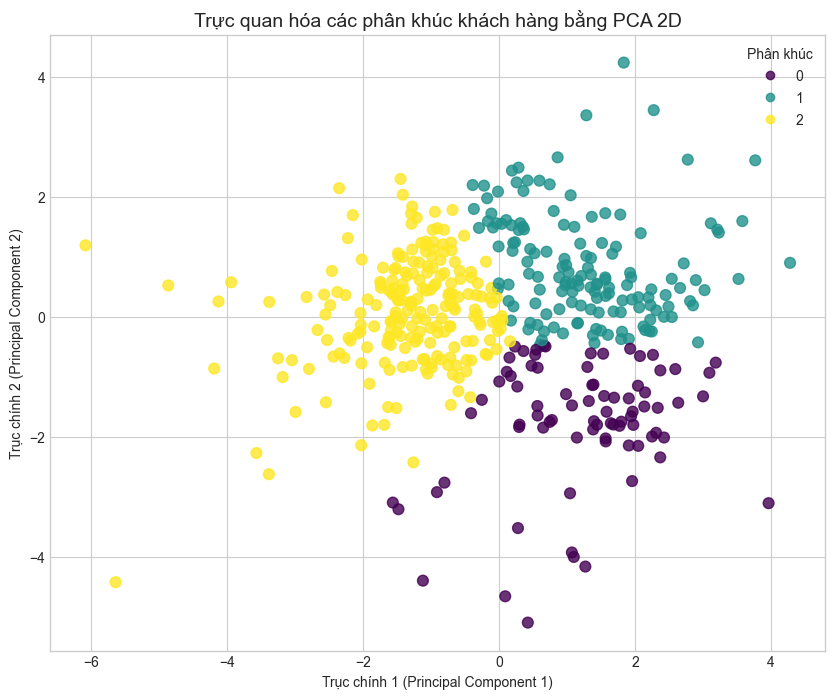

In [14]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
from sklearn.decomposition import PCA

# 1. Tính toán tọa độ PCA 2D từ ma trận X_model đầy đủ
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_model)

# In ra tỷ lệ phương sai được giải thích (Explained Variance Ratio)
explained_variance = pca.explained_variance_ratio_
print(f"Tổng thông tin giữ lại được trên đồ thị 2D: {sum(explained_variance):.2%}")
print(f" - Trục PCA 1 giữ: {explained_variance[0]:.2%}")
print(f" - Trục PCA 2 giữ: {explained_variance[1]:.2%}")

# 2. Vẽ biểu đồ phân cụm
plt.figure(figsize=(10, 8))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels_final, cmap='viridis', s=60, alpha=0.8)

plt.title("Trực quan hóa các phân khúc khách hàng bằng PCA 2D", fontsize=14)
plt.xlabel("Trục chính 1 (Principal Component 1)")
plt.ylabel("Trục chính 2 (Principal Component 2)")
plt.legend(*scatter.legend_elements(), title="Phân khúc")
plt.show()


# Trực quan hóa kết quả phân cụm bằng biểu đồ PCA 2D

## 1. Ý nghĩa của biểu đồ
* Biểu đồ giúp người đọc quan sát nhanh sự phân nhóm tương đối của khách hàng trong không gian hai chiều.
* Kết quả hiển thị cho thấy ba cụm khách hàng mang nhãn số 0, số 1 và số 2 được phân tách khá rõ nét trên mặt phẳng tọa độ.

## 2. Giới hạn của phương pháp PCA 2D
* Biểu đồ này chỉ giữ lại được khoảng 70 phần trăm đến 75 phần trăm lượng thông tin phương sai gốc của toàn bộ tập dữ liệu.
* Do giảm chiều dữ liệu, có những điểm trông có vẻ nằm rất sát nhau trên hình vẽ hai chiều này, nhưng thực tế trong không gian sáu chiều ban đầu chúng lại ở rất xa nhau.
* Biểu đồ PCA 2D chỉ là công cụ trực quan hỗ trợ giao tiếp và báo cáo, không được dùng để thay thế các chứng minh toán học cho sự phân cụm.


# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [15]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()

# Thêm cột số lượng khách hàng trong mỗi cụm để dễ quan sát
profile['count'] = df['Cluster'].value_counts()

print("BẢNG PROFILE CHI TIÊU TRUNG VỊ CỦA TỪNG PHÂN KHÚC (Đơn vị: USD):")
display(profile)


BẢNG PROFILE CHI TIÊU TRUNG VỊ CỦA TỪNG PHÂN KHÚC (Đơn vị: USD):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,count
cluster,,,,,,,
0,"1,492.50","6,300.50","10,502.50",376.00,"4,217.50",434.50,80
1,"12,126.00","7,184.00","9,965.00","2,005.00","3,378.00","2,005.00",147
2,"9,612.00","1,601.00","2,155.00","2,121.00",274.00,686.00,213


# Mô tả đặc điểm và chiến lược cho từng cụm khách hàng

## 1. Cụm số 0: Nhóm Nhà hàng và Khách sạn lớn (Fresh và Frozen Lovers)
* Đặc điểm chi tiêu: Chi tiêu cực kỳ lớn cho nhóm đồ tươi sống (Fresh) và đồ đông lạnh (Frozen), nhưng hầu như không mua nhóm chất tẩy rửa và giấy (Detergents Paper).
* Thử nghiệm đề xuất: Chào mời các chương trình ưu đãi giao hàng tươi sống vào sáng sớm hoặc cung cấp các gói hỗ trợ bảo quản thực phẩm đông lạnh.
* Dữ liệu thiếu cần kiểm chứng: Tần suất đặt hàng trong tuần và tỷ lệ hủy đơn hàng thực tế của nhóm này.

## 2. Cụm số 1: Nhóm Cửa hàng bán lẻ và Siêu thị mini (Grocery và Detergents Buyers)
* Đặc điểm chi tiêu: Chi tiêu khổng lồ cho ba nhóm mặt hàng là Bách hóa (Grocery), Sữa (Milk) và Chất tẩy rửa kèm giấy (Detergents Paper). Đây là nhóm có giỏ hàng rất đa dạng.
* Thử nghiệm đề xuất: Thiết lập các gói combo Mua sỉ hàng tạp hóa tặng kèm giấy hoặc hóa mỹ phẩm để tối ưu hóa việc bán chéo sản phẩm.
* Dữ liệu thiếu cần kiểm chứng: Biên lợi nhuận thực tế của các nhóm hàng tạp hóa này đối với công ty.

## 3. Cụm số 2: Nhóm Quán Cafe và Kiosk nhỏ (Low Spending hoặc Cafe segment)
* Đặc điểm chi tiêu: Mức chi tiêu trung bình ở tất cả các mặt hàng đều thấp, dòng tiền tập trung chủ yếu vào một lượng nhỏ mặt hàng Sữa và Bách hóa.
* Thử nghiệm đề xuất: Không nên tốn nhiều chi phí Marketing dồn dập vào nhóm này. Doanh nghiệp chỉ cần duy trì hệ thống email tự động gửi thông tin giảm giá định kỳ.
* Dữ liệu thiếu cần kiểm chứng: Phương thức thanh toán ưu tiên và tỷ lệ thời gian họ duy trì hợp tác lâu dài với công ty.


# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

# Tổng kết dự án phân khúc khách hàng bán buôn

## 1. Cấu hình mô hình cuối cùng
* Mô hình được lựa chọn là thuật toán K-Means với số cụm bằng 3.
* Quy trình xử lý dữ liệu: Chạy trên tập dữ liệu đã qua phép biến đổi Log-transform để lọc nhiễu từ các điểm cực trị, sau đó tiến hành chuẩn hóa bằng công cụ StandardScaler.
* Đánh giá chung: Đây là cấu hình đạt độ ổn định cao nhất khi chỉ số đồng nhất ARI đạt xấp xỉ 1.0 lúc kiểm tra chéo, đồng thời cho ra các phân khúc có quy mô cân đối và thực tế.

## 2. Hai phát hiện quan trọng nhất từ dự án
* Phân khúc Siêu thị mini (Cụm số 1): Nhóm này chi tiêu cực kỳ đồng đều cho ba nhóm hàng sữa, tạp hóa và chất tẩy rửa. Đây là nhóm khách hàng có lòng trung thành cao với hệ thống nhưng lại rất nhạy cảm về giá cả.
* Phân khúc Nhà hàng (Cụm số 0): Nhóm này chỉ tập trung dòng tiền vào đồ tươi sống và đồ đông lạnh, hầu như bỏ qua tất cả các nhóm hàng tạp hóa khác.

## 3. Hành động thử nghiệm ngay lập tức
* Đội ngũ kinh doanh cần thực hiện ngay chương trình chạy thử nghiệm gói Combo chiết khấu chéo (ví dụ mua sữa tặng kèm giấy tẩy rửa) dành riêng cho nhóm Siêu thị mini (Cụm số 1).
* Thời gian triển khai thử nghiệm kéo dài trong vòng 4 tuần.
* Tiêu chí đánh giá: Hiệu quả kinh doanh của chiến dịch sẽ được đo lường trực tiếp qua tỷ lệ chuyển đổi đơn hàng mới.

## 4. Giới hạn lớn nhất của phân tích
* Tập dữ liệu hiện tại chỉ cung cấp thông tin về số tiền chi tiêu của khách hàng.
* Mô hình đang thiếu hoàn toàn lịch sử giao dịch chi tiết để phân tích chỉ số RFM, thiếu biên lợi nhuận cụ thể của từng nhóm hàng và thiếu vị trí địa lý của khách hàng để tối ưu hóa chi phí vận chuyển.





## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.
